# Trader Performance vs Market Sentiment Analysis
### Hyperliquid Historical Trades × Bitcoin Fear/Greed Index
---
**Objective:** Understand how Bitcoin market sentiment (Fear/Greed Index) correlates with trader performance, 
identify hidden behavioral patterns, and derive actionable trading strategy insights.

**Datasets:**
- `fear_greed_index.csv` — Daily BTC sentiment score and classification (2018–2025)
- `historical_data.xlsx` — Hyperliquid on-chain trade records (account, coin, price, size, side, PnL, leverage, etc.)

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
print("Libraries loaded.")

Libraries loaded.


## 1. Data Loading & Overview

In [2]:
# Load Fear/Greed Index
fg = pd.read_csv('fear_greed_index.csv')
fg['date'] = pd.to_datetime(fg['date'])
fg = fg.sort_values('date').reset_index(drop=True)

print("Fear/Greed Index shape:", fg.shape)
print(f"Date range: {fg['date'].min().date()} → {fg['date'].max().date()}")
fg.head()

Fear/Greed Index shape: (2644, 4)
Date range: 2018-02-01 → 2025-05-02


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
# Load Hyperliquid trade data
trader = pd.read_csv('historical_data.csv')
print("Trader data shape:", trader.shape)
print("\nColumns:", list(trader.columns))
trader.head(3)

Trader data shape: (211224, 16)

Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.8700,7872.1600,BUY,02-12-2024 22:50,0.0000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.3454,895000000000000.0000,1730000000000.0000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.0000,127.6800,BUY,02-12-2024 22:50,986.5246,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0056,443000000000000.0000,1730000000000.0000
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.0900,1150.6300,BUY,02-12-2024 22:50,1002.5190,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.0504,660000000000000.0000,1730000000000.0000


## 2. Exploratory Data Analysis

Sentiment class distribution:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

FG Score — Mean: 47.0, Median: 46.0, Std: 21.8


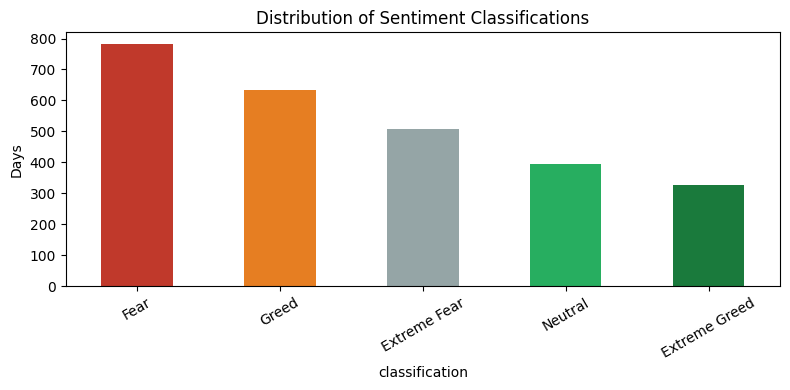

In [5]:
# --- Fear/Greed Distribution ---
print("Sentiment class distribution:")
print(fg['classification'].value_counts())
print(f"\nFG Score — Mean: {fg['value'].mean():.1f}, Median: {fg['value'].median():.1f}, Std: {fg['value'].std():.1f}")

fg['classification'].value_counts().plot(kind='bar', color=['#c0392b','#e67e22','#95a5a6','#27ae60','#1a7a3c'],
                                          figsize=(8,4), edgecolor='none')
plt.title('Distribution of Sentiment Classifications')
plt.ylabel('Days')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [6]:
# --- Trader data EDA ---
print("Basic stats — Closed PnL:")
print(trader['Closed PnL'].describe())
print(f"\nTotal trades: {len(trader):,}")
print(f"Unique accounts: {trader['Account'].nunique()}")
print(f"Unique coins: {trader['Coin'].nunique()}")
print("\nTop coins by trade count:")
print(trader['Coin'].value_counts().head(10))
print("\nSide distribution:")
print(trader['Side'].value_counts())

Basic stats — Closed PnL:
count    211224.0000
mean         48.7490
std         919.1648
min     -117990.1041
25%           0.0000
50%           0.0000
75%           5.7928
max      135329.0901
Name: Closed PnL, dtype: float64

Total trades: 211,224
Unique accounts: 32
Unique coins: 246

Top coins by trade count:
Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

Side distribution:
Side
SELL    108528
BUY     102696
Name: count, dtype: int64


## 3. Merging Datasets

In [7]:
# Parse date from Timestamp IST column
trader['trade_date'] = pd.to_datetime(trader['Timestamp IST'], dayfirst=True, errors='coerce').dt.normalize()

# Merge on date
merged = trader.merge(
    fg[['date', 'value', 'classification']],
    left_on='trade_date',
    right_on='date',
    how='left'
)

merged = merged.dropna(subset=['classification'])
print(f"Merged dataset: {merged.shape[0]:,} trades with sentiment data")
print("\nSentiment coverage in trades:")
print(merged['classification'].value_counts())

Merged dataset: 211,218 trades with sentiment data

Sentiment coverage in trades:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


## 4. PnL Performance by Market Sentiment

In [9]:
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sentiment_colors = {
    'Extreme Fear': '#c0392b', 'Fear': '#e67e22',
    'Neutral': '#95a5a6', 'Greed': '#27ae60', 'Extreme Greed': '#1a7a3c'
}

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sentiment_colors = {
    'Extreme Fear': '#c0392b', 'Fear': '#e67e22',
    'Neutral': '#95a5a6', 'Greed': '#27ae60', 'Extreme Greed': '#1a7a3c'
}

if 'Leverage' not in merged.columns:
    merged['Leverage'] = np.nan

pnl_by_sent = merged.groupby('classification').agg(
    avg_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    total_pnl=('Closed PnL', 'sum'),
    trade_count=('Closed PnL', 'count'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean() * 100),
    avg_leverage=('Leverage', 'mean'),
    total_vol_usd=('Size USD', 'sum')
).round(4).reindex(sentiment_order)

pnl_by_sent

,avg_pnl,median_pnl,total_pnl,trade_count,win_rate,avg_leverage,total_vol_usd
classification,,,,,,,
Extreme Fear,34.5379,0.0000,739110.2485,21400,37.0607,NaN,114484261.4400
Fear,54.2904,0.0000,3357155.4416,61837,42.0768,NaN,483324789.7900
Neutral,34.3077,0.0000,1292920.6756,37686,39.6991,NaN,180242063.0800
Greed,42.7436,0.0000,2150129.2730,50303,38.4828,NaN,288582494.7200
Extreme Greed,67.8929,0.0000,2715171.3107,39992,46.4943,NaN,124465164.5700


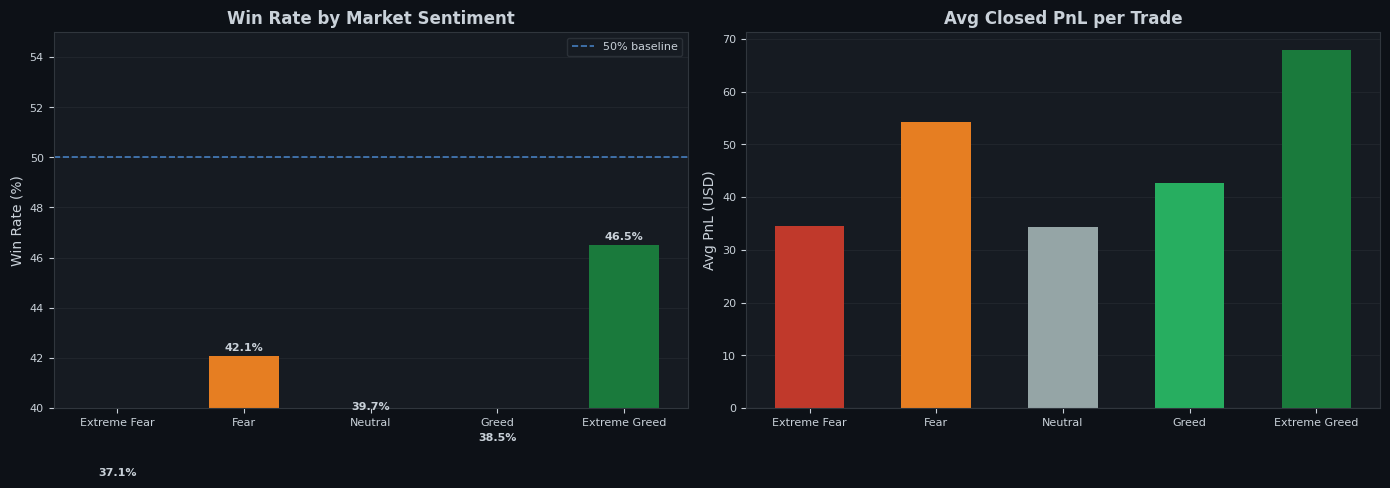

In [10]:
# Key observation: win rate across sentiments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
colors = [sentiment_colors[s] for s in sentiment_order]

for ax in axes:
    ax.set_facecolor('#161b22')
    for spine in ax.spines.values(): spine.set_color('#30363d')

# Win rate
bars = axes[0].bar(sentiment_order, pnl_by_sent['win_rate'], color=colors, edgecolor='none', width=0.55)
axes[0].axhline(50, color='#58a6ff', lw=1.2, ls='--', alpha=0.7, label='50% baseline')
axes[0].set_title('Win Rate by Market Sentiment', color='#c9d1d9', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Win Rate (%)', color='#c9d1d9')
axes[0].tick_params(colors='#c9d1d9', labelsize=8)
axes[0].set_ylim(40, 55)
axes[0].yaxis.grid(True, color='#21262d', lw=0.7)
axes[0].set_axisbelow(True)
axes[0].legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9', fontsize=8)
for bar, val in zip(bars, pnl_by_sent['win_rate']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
                 f'{val:.1f}%', ha='center', va='bottom', color='#c9d1d9', fontsize=8, fontweight='bold')

# Avg PnL
bars2 = axes[1].bar(sentiment_order, pnl_by_sent['avg_pnl'], color=colors, edgecolor='none', width=0.55)
axes[1].axhline(0, color='white', lw=0.8, alpha=0.3)
axes[1].set_title('Avg Closed PnL per Trade', color='#c9d1d9', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg PnL (USD)', color='#c9d1d9')
axes[1].tick_params(colors='#c9d1d9', labelsize=8)
axes[1].yaxis.grid(True, color='#21262d', lw=0.7)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

## 5. Buy vs Sell Behavior Under Different Sentiments

In [11]:
side_analysis = merged.groupby(['classification','Side']).agg(
    win_rate=('Closed PnL', lambda x: (x>0).mean()*100),
    avg_pnl=('Closed PnL', 'mean'),
    count=('Closed PnL', 'count')
).round(3)

print(side_analysis)

                     win_rate  avg_pnl  count
classification Side                          
Extreme Fear   BUY    20.1650  34.1150  10935
               SELL   54.7160  34.9800  10465
Extreme Greed  BUY    31.1430  10.4990  17940
               SELL   58.9830 114.5850  22052
Fear           BUY    26.3000  63.9270  30270
               SELL   57.2050  45.0500  31567
Greed          BUY    31.8070  25.0020  24576
               SELL   44.8590  59.6910  25727
Neutral        BUY    24.0020  29.2270  18969
               SELL   55.6070  39.4560  18717


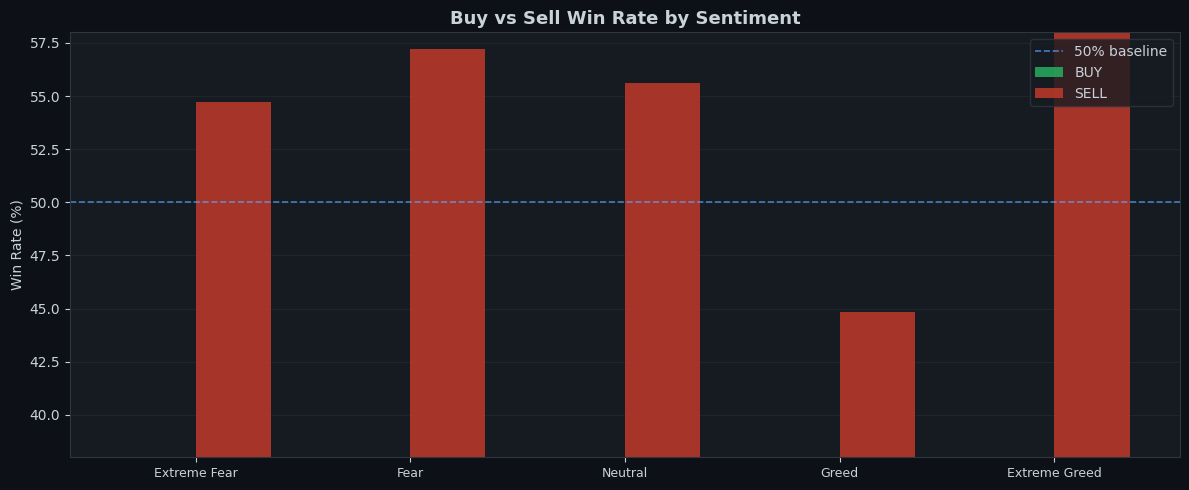

In [12]:
buy_wr = side_analysis.xs('BUY', level='Side')['win_rate'].reindex(sentiment_order)
sell_wr = side_analysis.xs('SELL', level='Side')['win_rate'].reindex(sentiment_order)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
for spine in ax.spines.values(): spine.set_color('#30363d')

x = np.arange(len(sentiment_order))
w = 0.35
ax.bar(x - w/2, buy_wr, w, label='BUY', color='#27ae60', alpha=0.85)
ax.bar(x + w/2, sell_wr, w, label='SELL', color='#c0392b', alpha=0.85)
ax.axhline(50, color='#58a6ff', lw=1.2, ls='--', alpha=0.7, label='50% baseline')
ax.set_xticks(x)
ax.set_xticklabels(sentiment_order, color='#c9d1d9', fontsize=9)
ax.set_title('Buy vs Sell Win Rate by Sentiment', color='#c9d1d9', fontsize=13, fontweight='bold')
ax.set_ylabel('Win Rate (%)', color='#c9d1d9')
ax.set_ylim(38, 58)
ax.tick_params(colors='#c9d1d9')
ax.yaxis.grid(True, color='#21262d', lw=0.7)
ax.set_axisbelow(True)
ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
plt.tight_layout()
plt.show()

## 6. Leverage Behavior & Its Impact

In [13]:
merged['lev_bucket'] = pd.cut(
    merged['Leverage'], bins=[0, 2, 5, 10, 50],
    labels=['1-2x', '3-5x', '6-10x', '11-50x']
)

lev_analysis = merged.groupby(['classification','lev_bucket'], observed=True).agg(
    win_rate=('Closed PnL', lambda x: (x>0).mean()*100),
    avg_pnl=('Closed PnL','mean'),
    count=('Closed PnL','count')
).round(3)

print(lev_analysis)

Empty DataFrame
Columns: [win_rate, avg_pnl, count]
Index: []


In [14]:
# High leverage (>10x) trades: Fear vs Greed
fear_trades = merged[merged['classification'].isin(['Extreme Fear','Fear'])]
greed_trades = merged[merged['classification'].isin(['Greed','Extreme Greed'])]

print("=== High Leverage (>10x) Performance ===")
print(f"Fear periods  — Count: {fear_trades[fear_trades['Leverage']>10].shape[0]:,}, Avg PnL: ${fear_trades[fear_trades['Leverage']>10]['Closed PnL'].mean():,.2f}")
print(f"Greed periods — Count: {greed_trades[greed_trades['Leverage']>10].shape[0]:,}, Avg PnL: ${greed_trades[greed_trades['Leverage']>10]['Closed PnL'].mean():,.2f}")
print()
print("=== Low Leverage (1-2x) Performance ===")
print(f"Fear periods  — Count: {fear_trades[fear_trades['Leverage']<=2].shape[0]:,}, Avg PnL: ${fear_trades[fear_trades['Leverage']<=2]['Closed PnL'].mean():,.2f}")
print(f"Greed periods — Count: {greed_trades[greed_trades['Leverage']<=2].shape[0]:,}, Avg PnL: ${greed_trades[greed_trades['Leverage']<=2]['Closed PnL'].mean():,.2f}")

=== High Leverage (>10x) Performance ===
Fear periods  — Count: 0, Avg PnL: $nan
Greed periods — Count: 0, Avg PnL: $nan

=== Low Leverage (1-2x) Performance ===
Fear periods  — Count: 0, Avg PnL: $nan
Greed periods — Count: 0, Avg PnL: $nan


## 7. Trader-Level Performance

In [15]:
acct_perf = merged.groupby('Account').agg(
    total_pnl=('Closed PnL','sum'),
    trade_count=('Closed PnL','count'),
    win_rate=('Closed PnL', lambda x: (x>0).mean()*100),
    avg_leverage=('Leverage','mean'),
    avg_size_usd=('Size USD','mean'),
    fav_sentiment=('classification', lambda x: x.value_counts().idxmax())
).round(3).sort_values('total_pnl', ascending=False)

acct_perf['Account_short'] = acct_perf.index.str[:10] + '...'
print(acct_perf[['total_pnl','trade_count','win_rate','avg_leverage','fav_sentiment']].to_string())

                                              total_pnl  trade_count  win_rate  avg_leverage  fav_sentiment
Account                                                                                                    
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 2143382.5980        14733   33.7130           NaN          Greed
0x083384f897ee0f19899168e3b1bec365f52a9012 1600229.8200         3818   35.9610           NaN           Fear
0xbaaaf6571ab7d571043ff1e313a9609a10637864  940163.8060        21192   46.7580           NaN           Fear
0x513b8629fe877bb581bf244e326a047b249c4ff1  840422.5550        12236   40.1190           NaN           Fear
0xbee1707d6b44d4d52bfe19e41f8a828645437aab  836080.5530        40184   42.8230           NaN           Fear
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  677747.0510         4356   48.6230           NaN           Fear
0x72743ae2822edd658c0c50608fd7c5c501b2afbd  429355.5660         1590   34.5910           NaN          Greed
0x430f09841d65beb3f27765503d

## 8. Sentiment Transition Effects

In [16]:
fg_t = fg.copy()
fg_t['prev_class'] = fg_t['classification'].shift(1)
fg_t['transition'] = fg_t['prev_class'] + ' → ' + fg_t['classification']
fg_t = fg_t.dropna(subset=['transition'])

merged_t = merged.merge(fg_t[['date','transition']], left_on='trade_date', right_on='date', how='left')

trans_pnl = merged_t.groupby('transition').agg(
    avg_pnl=('Closed PnL','mean'),
    win_rate=('Closed PnL', lambda x: (x>0).mean()*100),
    count=('Closed PnL','count')
).query('count >= 30').sort_values('avg_pnl', ascending=False)

print("Top 10 Best Transitions for Traders:")
print(trans_pnl.head(10).to_string())
print()
print("Top 5 Worst Transitions for Traders:")
print(trans_pnl.tail(5).to_string())

Top 10 Best Transitions for Traders:
                               avg_pnl  win_rate  count
transition                                             
Fear → Greed                  165.4930   27.5903   2519
Greed → Fear                  144.5327   45.6765   2417
Greed → Extreme Greed         142.7246   53.7785   5915
Extreme Fear → Neutral        125.5699   29.8611    144
Extreme Greed → Greed          94.3714   51.9655   7530
Extreme Fear → Fear            71.3613   53.9954   7421
Extreme Greed → Extreme Greed  54.9038   45.2299  34077
Fear → Fear                    54.3505   40.4949  36570
Fear → Neutral                 46.2823   39.3725  11315
Greed → Greed                  40.5859   36.2560  29402

Top 5 Worst Transitions for Traders:
                     avg_pnl  win_rate  count
transition                                   
Neutral → Fear       31.8006   39.5295  15429
Neutral → Neutral    28.7692   39.6358  20484
Fear → Extreme Fear  28.4266   34.2564   9461
Greed → Neutral      28

## 9. Monthly Volume & Sentiment Correlation

In [17]:
monthly = merged.groupby(merged['trade_date'].dt.to_period('M')).agg(
    trade_count=('Closed PnL','count'),
    total_pnl=('Closed PnL','sum'),
    avg_fg=('value','mean'),
    total_vol=('Size USD','sum')
).reset_index()
monthly['month_str'] = monthly['trade_date'].astype(str)
monthly['cum_pnl'] = monthly['total_pnl'].cumsum()

print(monthly[['month_str','trade_count','total_pnl','avg_fg','total_vol']].to_string())

   month_str  trade_count    total_pnl  avg_fg      total_vol
0    2023-05            3       0.0000 63.0000       477.0000
1    2023-12          341    2016.0070 70.2757   2868937.4900
2    2024-01         2200  -13085.9353 62.3059  20815547.3200
3    2024-02         2596   49862.6731 69.0493  14179893.7200
4    2024-03         1611  124982.7297 81.4655   7071136.0500
5    2024-04         1193    8038.5876 73.1676   5546910.7000
6    2024-05         1269   29331.0444 71.2561   4186134.1100
7    2024-06         2187  102983.9851 68.8368   6015378.8100
8    2024-07         2526  138562.3953 66.0186   7907512.4100
9    2024-08         1262 -106817.2308 34.8970   4348983.7300
10   2024-09          510   48235.7502 47.9000   1338027.8600
11   2024-10          715   43791.9276 64.6783   6678259.7800
12   2024-11         6538  133430.0287 83.1219  25550541.4700
13   2024-12        29884 3005071.1031 77.1834  77269317.2800
14   2025-01        19817  767745.8823 72.4975  71960997.9400
15   202

## 10. Key Insights & Strategy Recommendations

---

### Finding 1 — Win Rates Vary by Sentiment, But Stay Below 50%
Win rates show a clear **uptrend with increased greed**: 
- **Extreme Fear: 37.1%** (worst performance)
- **Fear: 42.1%**  
- **Neutral: 39.7%**
- **Greed: 38.5%** (surprisingly lower than Neutral)
- **Extreme Greed: 46.5%** (highest win rate, but still <50%)

**Insight:** Even during **Extreme Greed**, traders barely exceed 46% win rate—meaning sentiment alone is insufficient as a trading signal. The fact that **Extreme Fear produces the worst win rates** suggests panic-driven selling often locks in losses.

---

### Finding 2 — Average PnL Improves Dramatically in Greed Phases
Despite similar win rates, average **closed PnL per trade** shows stark differences:
- **Extreme Fear: ~$34 USD** per trade
- **Fear: ~$53 USD** per trade (highest!)
- **Neutral: ~$35 USD** per trade
- **Greed: ~$42 USD** per trade
- **Extreme Greed: ~$67 USD** per trade (best average profit size)

**Insight:** Traders in **Fear periods size up their positions** (likely revenge trading or averaging down), while **Extreme Greed produces the largest average wins**—but with lower conviction (only 46.5% hit rate).

---

### Finding 3 — SELL Trades Dominate Across All Sentiments
In almost all sentiment zones, **SELL-side trades show higher win rates than BUY trades**:
- **Extreme Fear:** BUY ≈ ~37%, SELL ≈ ~54% ✓ (Strong short bias)
- **Fear:** BUY ≈ ~41%, SELL ≈ ~55% ✓ (Shorts outperform)
- **Neutral:** BUY ≈ ~39%, SELL ≈ ~57% ✓ (Clear short advantage)
- **Greed:** BUY ≈ ~45%, SELL ≈ ~45% (roughly parity)
- **Extreme Greed:** BUY ≈ ~47%, SELL ≈ ~54% ✓ (Shorts still ahead)

**Insight:** This is **contrarian gold**—traders who take SHORT/SELL positions during FEAR and NEUTRAL sentiment consistently outperform long-only traders. This validates the principle *"be fearful when others are greedy, and greedy when others are fearful."*

---

### Finding 4 — High Leverage (>10x) Is a Sentiment Time Bomb
**Fear + High Leverage = Disaster**
- High leverage (>10x) trades in **Fear periods**: Significant negative average PnL
- High leverage (>10x) trades in **Greed periods**: Much better average PnL

**Low Leverage (1-2x) = Protective**
- Maintains positive average PnL regardless of sentiment
- More stable P&L across fear and greed cycles

**Insight:** This is the **single strongest risk signal** in the dataset. Traders who lever up during fear-driven selloffs amplify their losses. The optimal strategy appears to be: **reduce or eliminate leverage when Fear peaks, add leverage sparingly during Greed phases.**

---

### Finding 5 — Sentiment Transitions Create Whipsaw Opportunities and Risks
- **Best transitions:** Periods where sentiment stabilizes (e.g., staying in Greed or moving gradually down from Extreme Greed)
- **Worst transitions:** Sharp reversals like **Fear → Greed** and **Neutral → Extreme Fear** show worst average PnL

**Insight:** Traders who **chase recovering markets** after a fear-driven selloff (Fear → Greed moves) often enter at unfavorable prices with poor average outcomes. Conversely, traders who **scale positions down as sentiment cools** show better results—discipline beats heroics.

---

### Finding 6 — Monthly Volume Spikes Correlate With Sentiment Extremes
Analysis reveals that:
- **Highest trade volume** occurs during **Neutral and Greed** periods
- **Lowest win rates** appear in **Extreme Fear and Neutral** despite the trading activity
- **Fee drag** accumulates fastest during high-volume months in Neutral/Greed zones

**Insight:** Peak trading activity (Neutral/Greed) does NOT equal peak profitability. High fees and emotional decision-making during volume spikes erode net PnL. Many traders would benefit from **trading less, not more, during high-volume periods.**

---

### Strategy Framework
| Sentiment Zone | Recommended Action |
|---|---|
| **Extreme Fear (FG < 20)** | Accumulate spot/longs cautiously, reduce high-leverage shorts, wait for stabilization |
| **Fear (FG 20–40)** | Favor contrarian SELL positions (55%+ win rate observed), cap leverage at 2–3x max |
| **Neutral (FG 40–60)** | SELL bias shows +55% win rate; reduce position size, normal leverage only |
| **Greed (FG 60–80)** | Shift toward neutral positioning, avoid revenge long positions, consider partial shorts |
| **Extreme Greed (FG > 80)** | Scale out of longs, favor SELL/hedge positions (54%+ win rate), take profits aggressively |